In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

In [2]:
import torch
import requests
import tempfile
from pathlib import Path
import shutil
from time import perf_counter_ns

from torchvision.utils import make_grid
from torchvision.transforms.v2.functional import to_pil_image
import matplotlib.pyplot as plt

In [3]:
def store_video_to(url:str, local_video_path:Path):
    response=requests.get(url, headers={'User-Agent':''})
    if response.status_code!=200: raise RuntimeError(f"Failed to download video. {response.status_code=}.")
    with open(local_video_path, 'wb') as f:
        for chunk in response.iter_content(): f.write(chunk)

def plot(frames:torch.Tensor, title:str|None=None):
    plt.rcParams['savefig.bbox']='tight'
    dpi=300
    fig, ax=plt.subplots(figsize=(800/dpi, 600/dpi), dpi=dpi)
    ax.imshow(to_pil_image(make_grid(frames)))
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    if title is not None: ax.set_title(title, fontsize=6)
    plt.tight_layout()

In [4]:
# Video source: https://www.pexels.com/video/an-african-penguin-at-the-beach-9140346/
# Author: Taryn Elliott.
url = "https://videos.pexels.com/video-files/9140346/9140346-uhd_3840_2160_25fps.mp4"
temp_dir=Path('D:/results/temp')
penguin_video_path=temp_dir/"penguin.mp4"
store_video_to(url, penguin_video_path)

from torchcodec.decoders import VideoDecoder
print(f"Penguin video metadata: {VideoDecoder(penguin_video_path).metadata}")

Penguin video metadata: VideoStreamMetadata:
  duration_seconds_from_header: 37.24
  begin_stream_seconds_from_header: 0.0
  bit_rate: 24879454.0
  codec: h264
  stream_index: 0
  duration_seconds: 37.24
  begin_stream_seconds: 0.0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 37.24
  width: 3840
  height: 2160
  num_frames_from_header: 931
  num_frames_from_content: 931
  average_fps_from_header: 25.0
  pixel_aspect_ratio: 0
  end_stream_seconds: 37.24
  num_frames: 931
  average_fps: 25.0



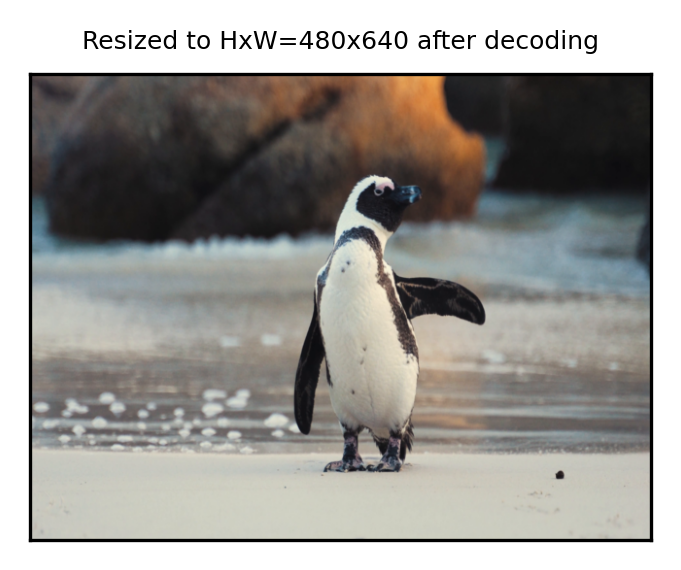

In [5]:
from torchvision.transforms import v2

full_decoder=VideoDecoder(penguin_video_path)
frame=full_decoder[5]
resized_after=v2.Resize(size=(480, 640))(frame) # (height, width) is Pytorch convention

plot(resized_after, title='Resized to HxW=480x640 after decoding')

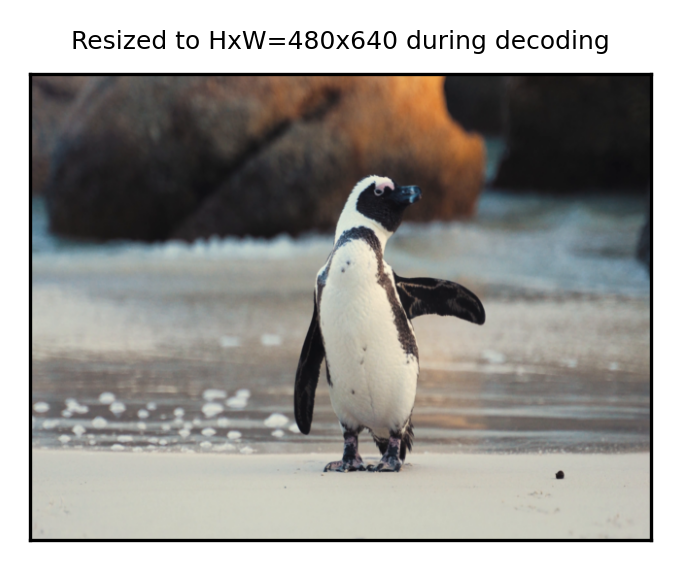

In [6]:
resize_decoder=VideoDecoder(penguin_video_path, transforms=[v2.Resize(size=(480, 640))])  # (height, width)
resized_during=resize_decoder[5]
plot(resized_during, title='Resized to HxW=480x640 during decoding')

abs_diff  tensor(2.) tensor(False)


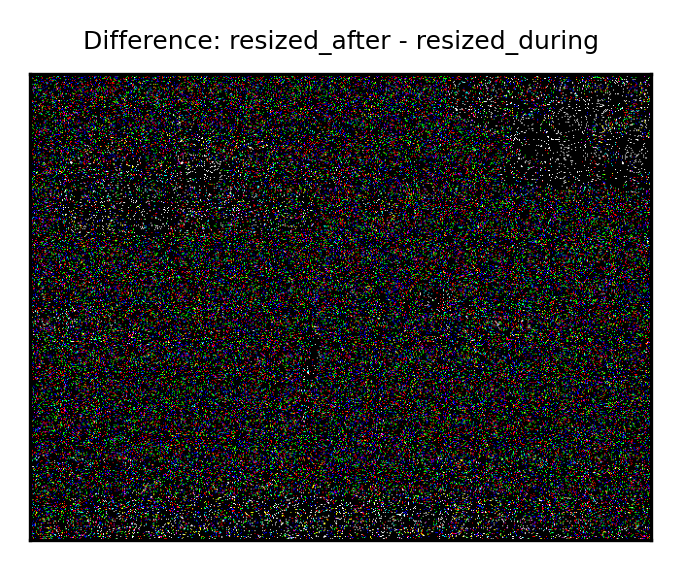

In [7]:
abs_diff = (resized_after.float() - resized_during.float()).abs()
print('abs_diff ', abs_diff.max(), (abs_diff==0).all())
plot(abs_diff, title='Difference: resized_after - resized_during')

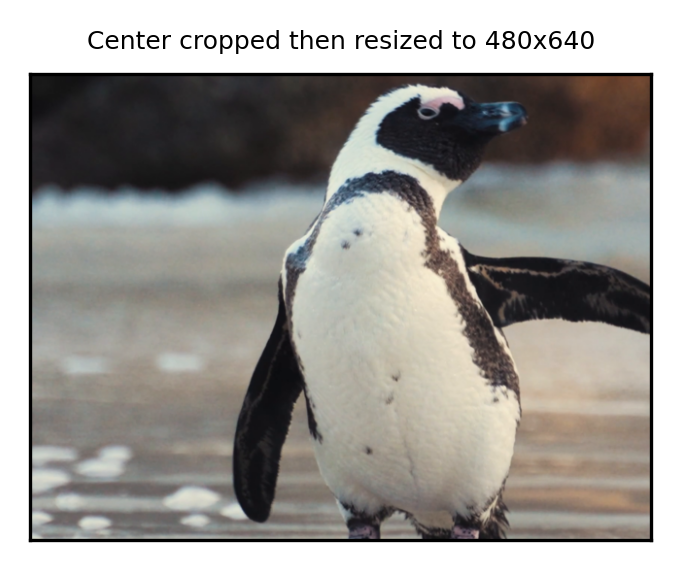

In [8]:
crop_resize_decoder=VideoDecoder(penguin_video_path, transforms=[v2.CenterCrop(size=(1280, 1664)), # (H,W)
                                                         v2.Resize(size=(480, 640))]) # (H,W)
crop_resized_during=crop_resize_decoder[5]
plot(crop_resized_during, title='Center cropped then resized to 480x640')

In [10]:
from torchcodec import samplers

def bench(f, average_over=3, warmup=1, **f_kwargs):
    for _ in range(warmup): f(**f_kwargs)

    times=[]
    for _ in range(average_over):
        start_time=perf_counter_ns()
        f(**f_kwargs)
        end_time=perf_counter_ns()
        times.append(end_time-start_time)

    times=torch.tensor(times)*1e-6 # nanoseconds to milliseconds
    times_std=times.std().item()
    times_med=times.median().item()
    return f"{times_med=:.2f} +- {times_std:.2f} ms"

def sampler_decoder_transforms(num_threads: int):
    decoder=VideoDecoder(penguin_video_path, transforms=[v2.CenterCrop(size=(1280, 1664)),
                                                         v2.Resize(size=(480, 640))],
                        seek_mode='approximate', num_ffmpeg_threads=num_threads)
    transformed_frames=samplers.clips_at_regular_indices(decoder, num_clips=1, num_frames_per_clip=200)
    assert len(transformed_frames.data[0])==200
    print(f'In sampler_decoder_transforms transformed_frames.data.shape {transformed_frames.data.shape}')

def sample_torchvision_transforms(num_threads: int):
    if num_threads>0: torch.set_num_threads(num_threads)
    decoder=VideoDecoder(penguin_video_path, seek_mode='approximate', num_ffmpeg_threads=num_threads)
    frames=samplers.clips_at_regular_indices(decoder, num_clips=1, num_frames_per_clip=200)
    transforms=v2.Compose([v2.CenterCrop(size=(1280, 1664)), v2.Resize(size=(480, 640))])
    transformed_frames=transforms(frames.data)
    assert transformed_frames.shape[1]==200
    print(f'In sample_torchvision_transforms transformed_frames.shape {transformed_frames.shape}')

# Setting num_threads of VideoDecoder to 0 means telling FFmpeg to automatically determine the number of threads based the availability on the system
print(f'decoder transforms: {bench(sampler_decoder_transforms, num_threads=0)}')
print(f'torchvision transform: {bench(sample_torchvision_transforms, num_threads=0)}')

In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
decoder transforms: times_med=842.82 +- 9.45 ms
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
torchvision transform: times_med=2278.94 +- 59.23 ms


In [11]:
print(f'decoder transforms: {bench(sampler_decoder_transforms, num_threads=1)}')
print(f'torchvision transform: {bench(sample_torchvision_transforms, num_threads=1)}')

In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
In sampler_decoder_transforms transformed_frames.data.shape torch.Size([1, 200, 3, 480, 640])
decoder transforms: times_med=9427.76 +- 39.52 ms
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
In sample_torchvision_transforms transformed_frames.shape torch.Size([1, 200, 3, 480, 640])
torchvision transform: times_med=8957.07 +- 14.86 ms
